In [1]:
%matplotlib inline

import os
import sys

sys.path.append('../../../../')

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [13]:
from __future__ import annotations
from typing import Optional, Union

import torch
import numpy as np

%load_ext autoreload
%autoreload 2

from computer_vision.slowfast.mmaction.datasets.transforms.loading import DecordInit, SampleFrames, DecordDecode

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
output_dirpath='D:/results/ucf101'
video_fpath=f'{output_dirpath}/demo.mp4'
assert os.path.isfile(video_fpath)

data=dict(filename=video_fpath, label=-1, start_index=0, modality='RGB')
print(f"{data=}")

# Create Decord
arguments={'type': 'DecordInit', 'io_backend': 'disk'}
arguments.pop('type')
decordinit=DecordInit(**arguments)
results=decordinit(data)
print(f'Decord-init: {results=}')

# Sample frames
arguments={'type': 'SampleFrames', 'clip_len': 32, 'frame_interval': 2, 'num_clips': 10, 'test_mode': True} #, 'target_fps':30}
arguments.pop('type')
sample_frames_op=SampleFrames(**arguments)
results=sample_frames_op(results)
print(f'Sample frames: {results=}')

decord_decode=DecordDecode()
results=decord_decode(results)
print(f'Decode: {results.keys()=}')

data={'filename': 'D:/results/ucf101/demo.mp4', 'label': -1, 'start_index': 0, 'modality': 'RGB'}
Decord-init: results={'filename': 'D:/results/ucf101/demo.mp4', 'label': -1, 'start_index': 0, 'modality': 'RGB', 'total_frames': 280, 'video_reader': <decord.video_reader.VideoReader object at 0x000001D925BCC910>, 'avg_fps': 28.0}
Sample frames: results={'filename': 'D:/results/ucf101/demo.mp4', 'label': -1, 'start_index': 0, 'modality': 'RGB', 'total_frames': 280, 'video_reader': <decord.video_reader.VideoReader object at 0x000001D925BCC910>, 'avg_fps': 28.0, 'frame_inds': array([  0,   2,   4,   6,   8,  10,  12,  14,  16,  18,  20,  22,  24,
        26,  28,  30,  32,  34,  36,  38,  40,  42,  44,  46,  48,  50,
        52,  54,  56,  58,  60,  62,  24,  26,  28,  30,  32,  34,  36,
        38,  40,  42,  44,  46,  48,  50,  52,  54,  56,  58,  60,  62,
        64,  66,  68,  70,  72,  74,  76,  78,  80,  82,  84,  86,  48,
        50,  52,  54,  56,  58,  60,  62,  64,  66,  68,  70, 

In [7]:
print(f"{type(results['imgs'])=}, {[x.shape for i, x in enumerate(results['imgs']) if i<4]}, {len(results['imgs'])=}")

type(results['imgs'])=<class 'list'>, [(256, 340, 3), (256, 340, 3), (256, 340, 3), (256, 340, 3)], len(results['imgs'])=320


In [14]:
sampled_imgs=np.stack(results['imgs']).transpose(0,3,1,2)[::10]
print(f"{sampled_imgs.shape=}")
sampled_imgs=torch.from_numpy(sampled_imgs)
sampled_imgs.shape

sampled_imgs.shape=(32, 3, 256, 340)


torch.Size([32, 3, 256, 340])

(-0.5, 2737.5, 1033.5, -0.5)

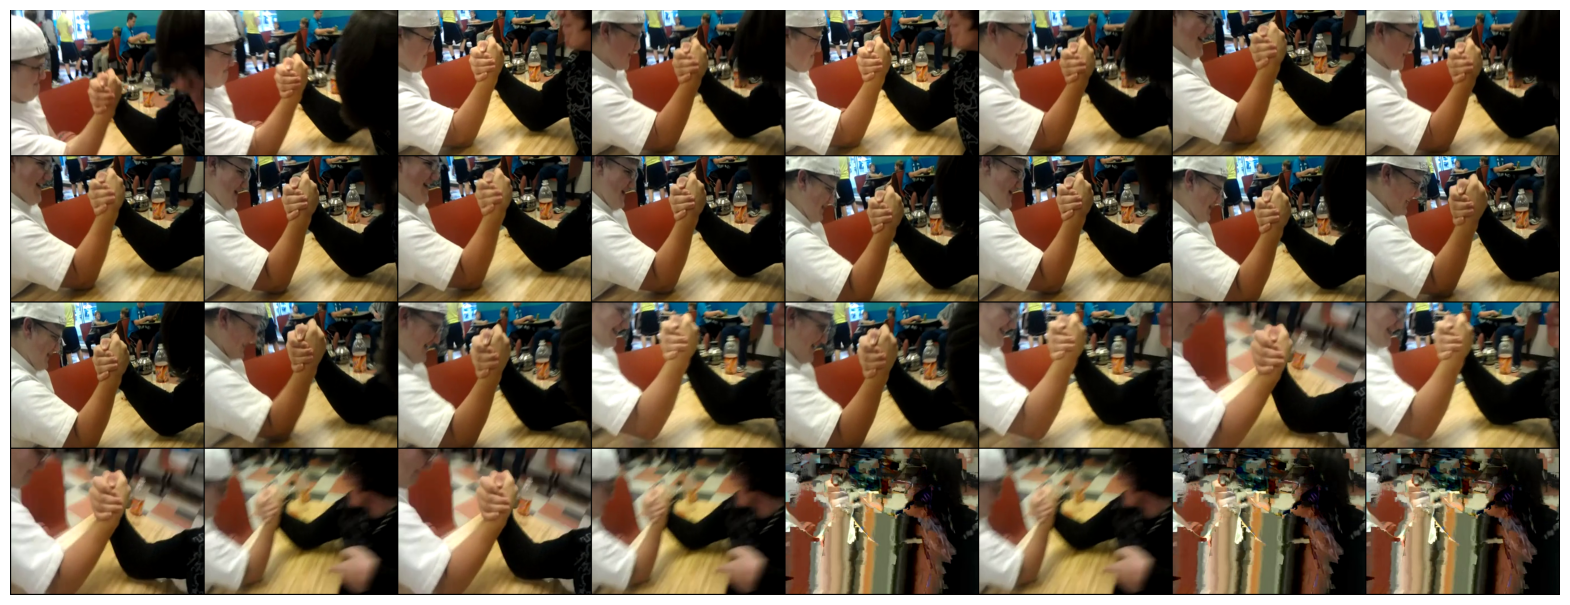

In [18]:
_, ax=plt.subplots(figsize=(20,20))
ax.imshow(make_grid(sampled_imgs).permute(1,2,0))
ax.axis("off")